In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd
import seaborn as sns
import tqdm

from networks import InvariantValueNet, ValueNet
from utils import get_batches

print(jax.devices())


[CudaDevice(id=0)]


In [2]:
random_key = jax.random.PRNGKey(42)

batch_size = 256
width = 256

value_net_equiv = InvariantValueNet(
    key=random_key,
    in_size=6 * 7 * 2,
    body_depth=2,
    body_width=width,
    embed_dim=width,
    activation=jax.nn.gelu,
    name="equiv",
)


value_net_nosym = ValueNet(
    key=random_key,
    in_size=6 * 7 * 2,
    body_depth=2,
    body_width=width,
    embed_dim=width,
    activation=jax.nn.gelu,
    avg_symmetries=False,
    name="nosym",
)

value_net_sym = ValueNet(
    key=random_key,
    in_size=6 * 7 * 2,
    body_depth=2,
    body_width=width,
    embed_dim=width,
    activation=jax.nn.gelu,
    avg_symmetries=True,
    name="sym",
)


In [3]:
opt = optax.adam(1e-3)

value_nets = [value_net_equiv, value_net_sym, value_net_nosym]
opts = []
for value_net in value_nets:
    params = eqx.filter(value_net, eqx.is_inexact_array)
    opts.append(opt.init(params))

_train_boards = np.load("data/train_boards.npy")
_train_values = np.load("data/train_values.npy")
_test_boards = np.load("data/test_boards.npy")
_test_values = np.load("data/test_values.npy")


n_train = _train_boards.shape[0]
n_sample = int(n_train * 0.1)
random_key, subkey = jax.random.split(random_key)
indices = jax.random.choice(subkey, n_train, shape=(n_sample,), replace=False)
train_boards = jnp.stack(
    [_train_boards[indices] == 1, _train_boards[indices] == 2], axis=-1
).astype(jnp.float32)
train_values = jnp.asarray(_train_values[indices], dtype=jnp.float32)
test_boards = jnp.stack([_test_boards == 1, _test_boards == 2], axis=-1).astype(
    jnp.float32
)
test_values = jnp.asarray(_test_values, dtype=jnp.float32)


n_epochs = 200
start_beta = 0.01
end_beta = 0.01

@eqx.filter_jit
def do_epoch(
    random_key,
    value_net,
    opt_state,
    obs,
    values,
    opt,
    batch_size,
    epochid,
    alpha=0.0,
    interm_alpha=0.0,
):
    params, static = eqx.partition(value_net, eqx.is_inexact_array)

    data = get_batches((obs, values), random_key, batch_size, drop_last=True)
    
    global_step = epochid * len(data[0])
    total_step = n_epochs * len(data[0])

    k = 0
    def body_fn(carry, x):
        params, opt_state, k = carry
        obs, values = x
        value_net = eqx.combine(params, static)

        beta = start_beta + (end_beta - start_beta) * ((global_step + k) / total_step)
        beta = jnp.asarray(beta, dtype=jnp.float32)
    
        (_, metrics), grads = eqx.filter_value_and_grad(loss_fn, has_aux=True)(
            value_net, obs, values, alpha, interm_alpha, beta
        )
        updates, opt_state = opt.update(grads, opt_state)
        value_net = eqx.apply_updates(value_net, updates)
        params = eqx.filter(value_net, eqx.is_inexact_array)
        return (params, opt_state, k + 1), (metrics)

    (params, opt_state, _), metrics = jax.lax.scan(body_fn, (params, opt_state, k), data)
    value_net = eqx.combine(params, static)
    return value_net, opt_state, metrics


@eqx.filter_jit
def loss_fn(value_net, obs, values, alpha=0.0, interm_alpha=0.0, beta=1.0):
    preds = jax.vmap(value_net.forward)(obs)

    if value_net.body.__class__.__name__ == "EquivariantMLP":
        qidloss = 0.0
        for l in value_net.body.layers:
            # q = (0.5) * (l.q + l.q.T)
            q = l.q
            qidloss +=  jnp.sum((jnp.eye(q.shape[0], dtype=q.dtype) - (q @ q))**2) / (width**2)
    else:
        qidloss = 0.0
        
    loss_main = jnp.mean((preds - values) ** 2)
    loss_l1 = jnp.mean(jnp.abs(preds - values))
    
    loss = loss_main + beta * qidloss

    return loss, {
        "value_loss": loss_main,
        "qidloss": qidloss,
        "l1_loss": loss_l1,
    }


In [4]:
rows = []
k = 0


def append_metrics_to_rows(rows, eval_lossdict, k, model_name="noname"):
    for key, value in eval_lossdict.items():
        row = {"value": float(value), "step": k, "metric": f"{model_name}_{key}"}
        rows.append(row)
    return rows


for value_net in value_nets:
    eval_loss_sym, eval_dict = loss_fn(value_net, test_boards, test_values)
    rows = append_metrics_to_rows(rows, eval_dict, k, value_net.name)

    if value_net.name == "nosym":
        value_net = eqx.combine(
            eqx.filter(value_net, eqx.is_inexact_array),
            eqx.filter(value_net_sym, lambda x: not eqx.is_inexact_array(x)),
        )
        rows = append_metrics_to_rows(rows, eval_dict, k, "nosym_evalsym")

In [ ]:
for epoch in tqdm.trange(n_epochs):
    random_key, subkey = jax.random.split(random_key)

    new_value_nets, new_opts = [], []
    for value_net, opt_state in zip(value_nets, opts):
        value_net, opt_state, metrics = do_epoch(
            subkey,
            value_net,
            opt_state,
            train_boards,
            train_values,
            opt,
            batch_size,
            jnp.asarray(epoch, dtype=jnp.int32),
        )
        new_value_nets.append(value_net)
        new_opts.append(opt_state)

    value_nets = new_value_nets
    opts = new_opts

    n_updates = len(metrics["value_loss"])
    k += n_updates

    for value_net in value_nets:
        eval_loss_sym, eval_dict = loss_fn(value_net, test_boards, test_values)
        rows = append_metrics_to_rows(rows, eval_dict, k, value_net.name)

        if value_net.name == "nosym":
            value_net = eqx.combine(
                eqx.filter(value_net, eqx.is_inexact_array),
                eqx.filter(value_net_sym, lambda x: not eqx.is_inexact_array(x)),
            )
            eval_loss_sym, eval_dict = loss_fn(value_net, test_boards, test_values)
            rows = append_metrics_to_rows(rows, eval_dict, k, "nosym_evalsym")


  0%|          | 0/200 [00:00<?, ?it/s]2026-04-21 18:40:04.834690: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-04-21 18:40:04.834998: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-04-21 18:40:08.301560: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-04-21 18:40:10.37

804
804
['equiv_qidloss', 'sym_qidloss', 'nosym_qidloss', 'nosym_evalsym_qidloss']


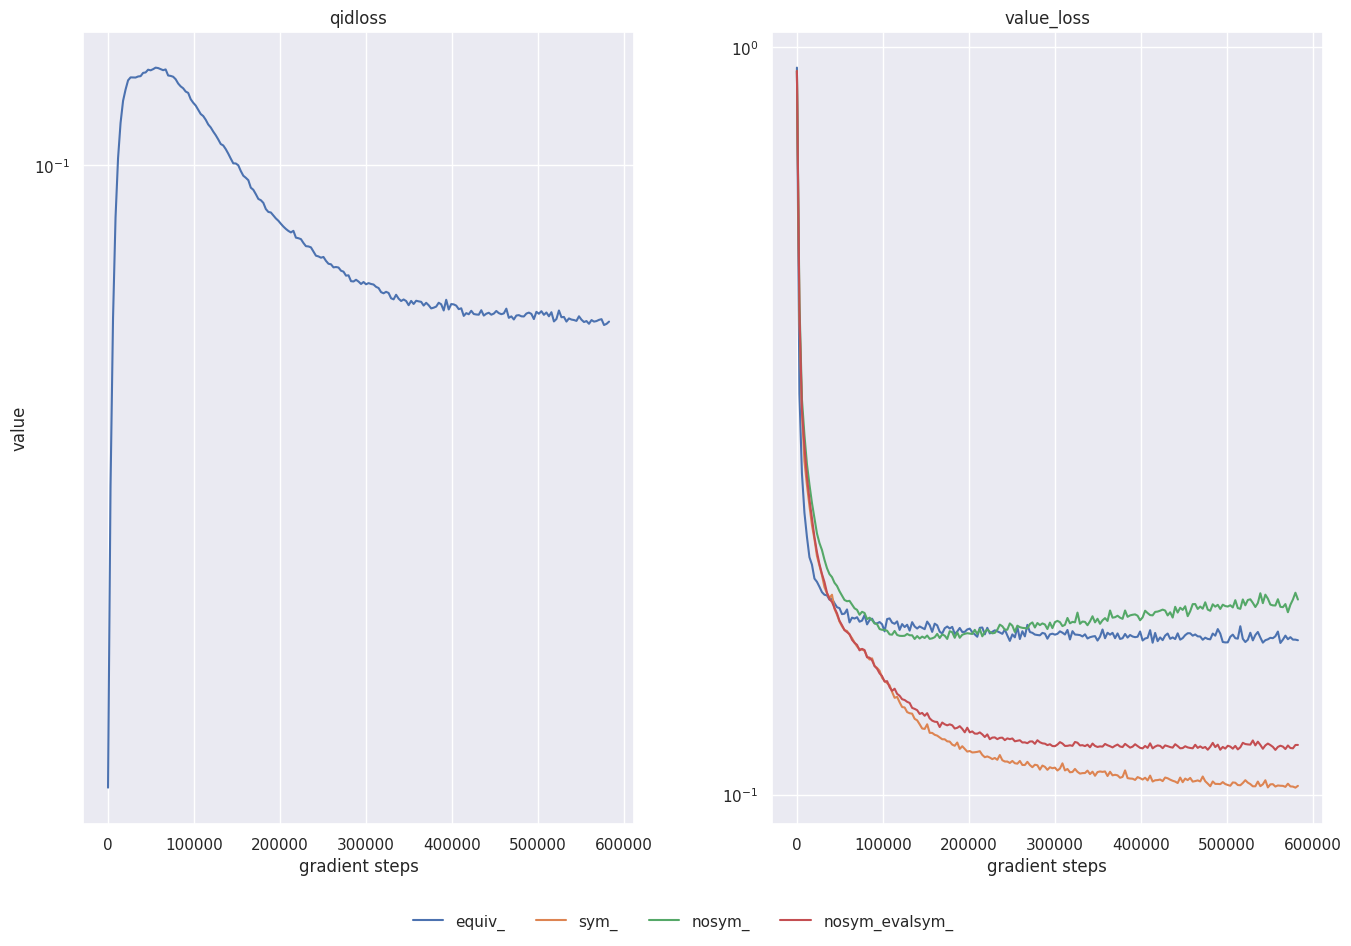

In [ ]:
df = pd.DataFrame(rows)
metric_keys = eval_dict.keys()
sns.set_theme()
plot_df_all = df
# plot_df_all = df[df.metric.str.contains("eval")].copy()
# plot_df_all.loc[:, "metric"] = plot_df_all["metric"].str.replace(r"^eval_", "", regex=True)

nrows, ncols = 1, 2
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(16, 12),
    sharex=True,
    sharey=False,
)
axes = axes.ravel()

max_plots = nrows * ncols
metric_keys = list(metric_keys)
n_plots = min(len(metric_keys), max_plots)


for i in range(n_plots):
    metricname = metric_keys[i]
    ax = axes[i]

    plot_df = plot_df_all[plot_df_all.metric.str.endswith(metricname)]
    print(len(plot_df))
    sns.lineplot(
        data=plot_df,
        x="step",
        y="value",
        hue="metric",
        ax=ax,
        legend=(i == 0),
    )

    ax.set_title(metricname)
    ax.set_yscale("log")

    if i >= (nrows - 1) * ncols:
        ax.set_xlabel("gradient steps")
    else:
        ax.set_xlabel("")

    if i % ncols != 0:
        ax.set_ylabel("")

    if i == 0:
        legend_handles, legend_labels = ax.get_legend_handles_labels()
        if ax.get_legend() is not None:
            ax.get_legend().remove()
    else:
        if ax.get_legend() is not None:
            ax.get_legend().remove()


    # ax.set_ylim(0, 1)
    
for j in range(n_plots, max_plots):
    fig.delaxes(axes[j])
    
legend_labels_short = []
legend_labels_suffix = legend_labels[0].split("_")[-1]
for lab in legend_labels:
    lab = lab.replace(legend_labels_suffix, "")
    legend_labels_short.append(lab)

print(legend_labels)

if legend_handles and legend_labels:
    fig.legend(
        legend_handles,
        legend_labels_short,
        loc="lower center",
        ncol=min(len(legend_labels), 6),
        frameon=False,
        bbox_to_anchor=(0.5, 0.12),
    )

fig.subplots_adjust(bottom=0.22, wspace=0.25, hspace=0.4)